Zadanie 3

Trening modelu SimpleRNN...
Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.6373 - loss: 0.6265 - val_accuracy: 0.8070 - val_loss: 0.4351
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.8386 - loss: 0.3778 - val_accuracy: 0.8232 - val_loss: 0.4448
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.8760 - loss: 0.3104 - val_accuracy: 0.8378 - val_loss: 0.3821
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9018 - loss: 0.2527 - val_accuracy: 0.8308 - val_loss: 0.3988
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9265 - loss: 0.1961 - val_accuracy: 0.8288 - val_loss: 0.4643
782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8283 - loss: 0.4665
Test accuracy (SimpleRNN): 0.8283
Trening modelu LSTM...
Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 23ms/step - accuracy: 0.7372 - loss: 0.5222 - val_accuracy: 0.8282 - val_loss: 0.3863
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step - accuracy: 0.8557 - los

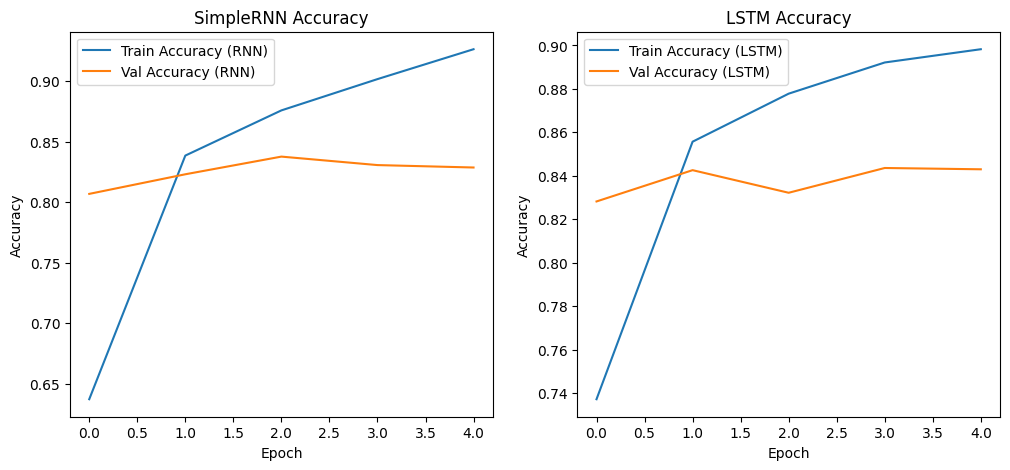

In [ ]:
import numpy as np
from tensorflow import keras
from tensorflow.keras.datasets import imdb
from tensorflow.keras.models import Sequential  
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense, LSTM, Dropout
from tensorflow.keras.preprocessing import sequence
import matplotlib.pyplot as plt 
from tensorflow.keras.optimizers import Adam

max_features = 5000 
maxlen = 100
learning_rate = 0.001

(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=max_features)
x_train = sequence.pad_sequences(x_train, maxlen=maxlen)
x_test = sequence.pad_sequences(x_test, maxlen=maxlen)

model_rnn = Sequential()
model_rnn.add(Embedding(max_features, 8, input_length=maxlen))
model_rnn.add(SimpleRNN(32))
model_rnn.add(Dense(1, activation='sigmoid'))
model_rnn.compile(optimizer=Adam(learning_rate=learning_rate), loss='binary_crossentropy', metrics=['accuracy'])
print("Trening modelu SimpleRNN...")
history_rnn = model_rnn.fit(x_train, y_train, epochs=5, batch_size=64, validation_split=0.2)
test_loss_rnn, test_acc_rnn = model_rnn.evaluate(x_test, y_test)
print(f"Test accuracy (SimpleRNN): {test_acc_rnn:.4f}") 

model_lstm = Sequential()
model_lstm.add(Embedding(max_features, 8, input_length=maxlen))
model_lstm.add(LSTM(64, dropout=0.2)) # recurrent_dropout=0.2))
model_lstm.add(Dense(1, activation='sigmoid'))
model_lstm.compile(optimizer=Adam(learning_rate=learning_rate), loss='binary_crossentropy', metrics=['accuracy'])
print("Trening modelu LSTM...")
history_lstm = model_lstm.fit(x_train, y_train, epochs=5, batch_size=64, validation_split=0.2)

test_loss_lstm, test_acc_lstm = model_lstm.evaluate(x_test, y_test)
print(f"Test accuracy (LSTM): {test_acc_lstm:.4f}")

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history_rnn.history['accuracy'], label='Train Accuracy (RNN)')
plt.plot(history_rnn.history['val_accuracy'], label='Val Accuracy (RNN)')
plt.title('SimpleRNN Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_lstm.history['accuracy'], label='Train Accuracy (LSTM)')
plt.plot(history_lstm.history['val_accuracy'], label='Val Accuracy (LSTM)')
plt.title('LSTM Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()


Zadanie 5

In [ ]:
import time
maxlen_values = [50, 100, 200, 500]
results = []

for maxlen in maxlen_values:    
    print(f"\nTrening modelu LSTM z maxlen={maxlen}...")

    x_train_padded = sequence.pad_sequences(x_train, maxlen=maxlen)
    x_test_padded = sequence.pad_sequences(x_test, maxlen=maxlen)

    model_lstm_exp = Sequential()
    model_lstm_exp.add(Embedding(max_features, 128, input_length=maxlen))
    model_lstm_exp.add(LSTM(64, dropout=0.2))
    model_lstm_exp.add(Dense(1, activation='sigmoid'))
    
    model_lstm_exp.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

    start_time = time.time()
    history = model_lstm_exp.fit(x_train_padded, y_train, epochs=5, batch_size=64, validation_split=0.2, verbose=0)
    end_time = time.time()
    training_time = end_time - start_time
    
    test_loss, test_acc = model_lstm_exp.evaluate(x_test_padded, y_test, verbose=0)
    results.append((maxlen, test_acc, training_time))
    print(f"maxlen={maxlen}: Test accuracy={test_acc:.4f}, Training time={training_time:.2f} seconds")

print("\nTabela wyników:")
print("maxlen | accuracy | training time (s)")
for maxlen, acc, time_sec in results:
    print(f"{maxlen:6} | {acc:.4f}   | {time_sec:.2f}")


Trening modelu LSTM z maxlen=50...
maxlen=50: Test accuracy=0.7958, Training time=23.63 seconds

Trening modelu LSTM z maxlen=100...
maxlen=100: Test accuracy=0.8400, Training time=55.42 seconds

Trening modelu LSTM z maxlen=200...
maxlen=200: Test accuracy=0.8324, Training time=100.88 seconds

Trening modelu LSTM z maxlen=500...
maxlen=500: Test accuracy=0.8397, Training time=252.35 seconds

Tabela wyników:
maxlen | accuracy | training time (s)
    50 | 0.7958   | 23.63
   100 | 0.8400   | 55.42
   200 | 0.8324   | 100.88
   500 | 0.8397   | 252.35


Zadanie 10

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step
Mean Squared Error: 0.1781
Mean Absolute Error: 0.3594


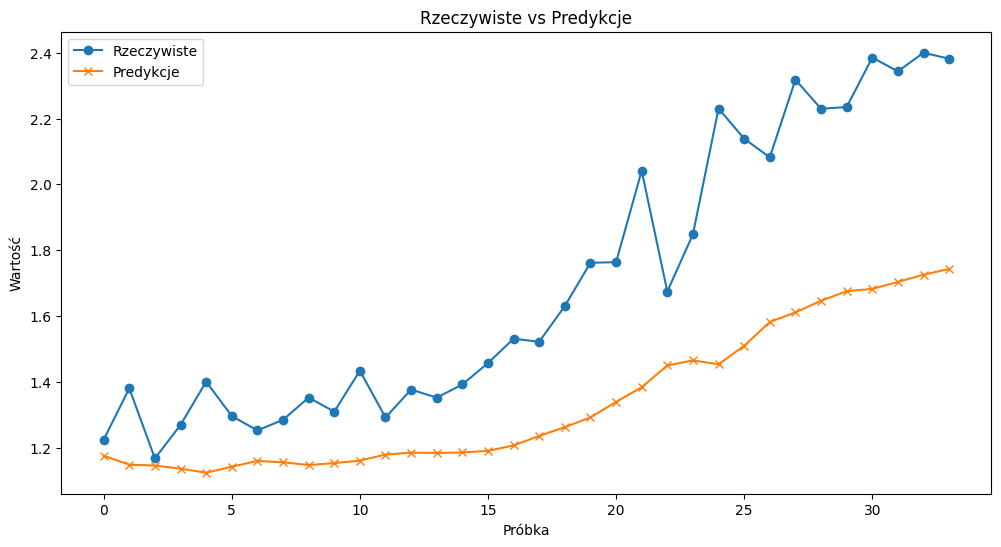

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential  
from tensorflow.keras.layers import GRU, Dense, Input
from sklearn.metrics import mean_squared_error, mean_absolute_error

def generate_time_series(n_samples=1000, n_steps=200):
    time = np.arange(n_steps)
    series = 0.5 * np.sin(0.1 * time) + 0.01 * time + 0.1 * np.random.randn(n_steps)
    return series   
series = generate_time_series()

def create_sequences(series, window_size=30):
    X, y = [], []
    for i in range(len(series) - window_size):
        X.append(series[i:i + window_size])
        y.append(series[i + window_size])
    return np.array(X), np.array(y)
window_size = 30
X, y = create_sequences(series, window_size)

split_index = int(len(X) * 0.8)
X_train, X_test = X[:split_index], X[split_index:]
y_train, y_test = y[:split_index], y[split_index:]

model_gru = Sequential()
model_gru.add(Input(shape=(window_size, 1)))
model_gru.add(GRU(128, dropout=0.2))
model_gru.add(Dense(1, activation='linear'))

model_gru.compile(optimizer='adam', loss='mse')

X_train_reshaped = X_train.reshape((X_train.shape[0], X_train.shape
[1], 1))
X_test_reshaped = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))
model_gru.fit(X_train_reshaped, y_train, epochs=20, batch_size=32, verbose=0)

y_pred = model_gru.predict(X_test_reshaped)

mse = mean_squared_error(y_test, y_pred)    
mae = mean_absolute_error(y_test, y_pred)
print(f"Mean Squared Error: {mse:.4f}")
print(f"Mean Absolute Error: {mae:.4f}")

plt.figure(figsize=(12, 6))
plt.plot(y_test, label='Rzeczywiste', marker='o')
plt.plot(y_pred, label='Predykcje', marker='x')
plt.title('Rzeczywiste vs Predykcje')
plt.xlabel('Próbka')
plt.ylabel('Wartość')   
plt.legend()
plt.show()  